# Hierarchical Clustering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/02-unsupervised-learning/hierarchical-clustering/notes.ipynb)

*Continues from the [K-Means++ notes](../k-means-plus-plus/notes.ipynb) — same closing question: if centroids are
the limitation, what's a completely different way to group points that doesn't use a center at all? This is that
different way: no centroids, no fixed K upfront — just repeated merging.*


## 1. A different starting point for grouping data

Centroid-based clustering (K-Means, K-Means++) works by picking centers and assigning each point to the nearest
one. That's fast, but it comes with two built-in assumptions: clusters are roughly round, and you have to decide
`K` before you even look at the data. Neither assumption holds for every dataset — crescent shapes, rings, and
uneven densities all break the "assign to nearest center" idea, and picking `K` blind is just a guess.

**Hierarchical (agglomerative) clustering drops both assumptions:** no centers, no fixed `K` upfront — just
repeated merging. Start by treating every point as its own tiny cluster, then repeatedly join the two *most
similar* clusters together, one pair at a time, until everything has merged into a single group.
"Agglomerative" simply means *building up by merging*.

**The core question this answers:** what's a way to group similar data points without relying on the idea of a
"center" at all?

**An everyday analogy:** think of a college party. Small groups form first, based on people who already know each
other. As the night goes on, groups gradually merge as more connections get discovered between them — nobody
picked "4 friend groups" in advance, the groups just emerged from repeated merging.


**Quick check**

> Do you have to decide the number of clusters, `K`, before you start — the way you do with K-Means?
>
> **No.** That's the central payoff of this approach — you build the *entire* merge history first, then decide
> how many groups you want by looking at it. It becomes much clearer once you see a dendrogram, in Section 4.


## 2. Agglomerative mechanics: a toy walkthrough

Before real data, it helps to watch the merging happen on a tiny, obvious dataset: six points arranged as three
clearly-paired dots.


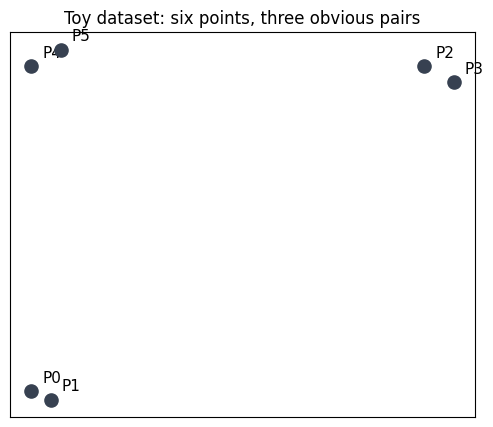

In [1]:
import numpy as np
import matplotlib.pyplot as plt

toy_points = np.array([
    [1.0, 1.0],   # P0
    [1.2, 0.9],   # P1
    [5.0, 5.0],   # P2
    [5.3, 4.8],   # P3
    [1.0, 5.0],   # P4
    [1.3, 5.2],   # P5
])
toy_labels = ["P0", "P1", "P2", "P3", "P4", "P5"]

plt.figure(figsize=(6, 5))
plt.scatter(toy_points[:, 0], toy_points[:, 1], s=90, color="#374151", zorder=5)
for (x, y), label in zip(toy_points, toy_labels):
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(8, 6), fontsize=11)
plt.title("Toy dataset: six points, three obvious pairs")
plt.xticks([]); plt.yticks([])
plt.show()

**The algorithm, in four steps:**

1. **Start** — every point is its own cluster. Six points, six clusters.
2. **Find the two closest clusters, merge them into one.**
3. **Repeat** — treat the newly merged cluster as a single cluster and find the next closest pair, merge again.
4. **Keep merging** until every point belongs to one giant cluster.

On this toy dataset: (P0, P1) merge first, then (P2, P3), then (P4, P5) — the three obvious pairs. After that,
the algorithm keeps merging these three pairs together with each other until everything is one cluster. The
*order* in which the pairs themselves get merged (P0P1 with P2P3 first, or with P4P5 first) is exactly what a
**linkage criterion** decides — covered next.

On nicely separated, spherical blobs like this one, agglomerative clustering usually agrees with K-Means. The
real differences show up on messier data — and on how much control you get over *how* clusters merge, which is
exactly what linkage criteria decide.


```{mermaid}
graph TD
    A["1. Start<br/>every point is its own cluster"] --> B["2. Find the two closest clusters<br/>merge them into one"]
    B --> C["3. Repeat<br/>treat the merged cluster as one, find next closest pair"]
    C -->|not done yet| B
    C -->|only one cluster left| D["4. Done<br/>full merge hierarchy built"]

    style A fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style B fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style C fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style D fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
```

**Quick check**

> What is the core mechanic that drives agglomerative hierarchical clustering?
>
> Repeatedly merge the two closest clusters, starting from every point as its own cluster — not randomly
> initializing centroids, not drawing circles around a fixed center, not randomly splitting the data.


## 3. Linkage criteria and how they compare

"Merge the two closest clusters" sounds simple — but once a cluster has more than one point in it, how do you
measure the distance *between two clusters*? That choice is called the **linkage criterion**, and it determines
the order in which clusters merge, which can dramatically change the final structure.

| Linkage | Distance between two clusters is defined as |
|---|---|
| **Single** | the distance between their *closest* pair of points |
| **Complete** | the distance between their *farthest* pair of points |
| **Average** | the average distance across *all* pairs of points |
| **Ward** | the increase in total within-cluster variance after merging |

The table describes *what's measured*, but it's easier to see once it's drawn: same two little clusters, four
different things being measured between them.


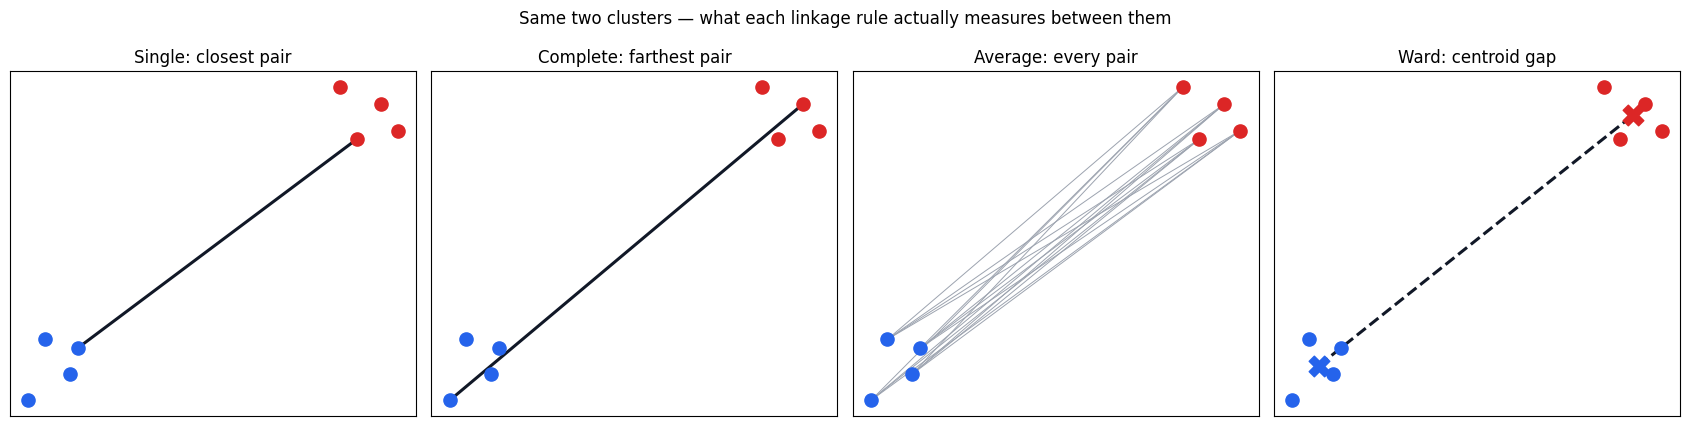

In [2]:
A = np.array([[0.0, 0.0], [0.5, 0.3], [0.2, 0.7], [0.6, 0.6]])
B = np.array([[4.0, 3.0], [4.3, 3.4], [3.8, 3.6], [4.5, 3.1]])

# find the closest pair (single linkage) and farthest pair (complete linkage)
dists = np.linalg.norm(A[:, None, :] - B[None, :, :], axis=2)
i_min, j_min = np.unravel_index(np.argmin(dists), dists.shape)
i_max, j_max = np.unravel_index(np.argmax(dists), dists.shape)
centroid_a, centroid_b = A.mean(axis=0), B.mean(axis=0)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.3))
titles = ["Single: closest pair", "Complete: farthest pair", "Average: every pair", "Ward: centroid gap"]

for ax, title in zip(axes, titles):
    ax.scatter(*A.T, s=90, color="#2563EB", zorder=5)
    ax.scatter(*B.T, s=90, color="#DC2626", zorder=5)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

axes[0].plot(*zip(A[i_min], B[j_min]), color="#111827", linewidth=2.2)
axes[1].plot(*zip(A[i_max], B[j_max]), color="#111827", linewidth=2.2)
for a in A:
    for b in B:
        axes[2].plot(*zip(a, b), color="#9CA3AF", linewidth=0.7, zorder=1)
axes[3].scatter(*centroid_a, s=220, marker="X", color="#2563EB", zorder=6)
axes[3].scatter(*centroid_b, s=220, marker="X", color="#DC2626", zorder=6)
axes[3].plot(*zip(centroid_a, centroid_b), color="#111827", linewidth=2.2, linestyle="--")

plt.suptitle("Same two clusters — what each linkage rule actually measures between them")
plt.tight_layout()
plt.show()

- **Single** only looks at the single nearest pair of points (the black line) — one close pair is enough to call
  the clusters "near."
- **Complete** only looks at the single farthest pair — even the two most different points have to be close.
- **Average** looks at *every* pair between the two clusters (all the faint gray lines) and takes the mean.
- **Ward** ignores individual points entirely and compares the two cluster centroids (X marks), weighted by
  cluster size.

In every formula below, $A$ and $B$ are two clusters and $d(a, b)$ is the distance (usually Euclidean) between
points $a$ and $b$.

### Single linkage (nearest neighbor)

$$
D(A, B) = \min_{a \in A,\ b \in B} d(a, b)
$$

Since single linkage only cares about the single closest pair of points, even one "bridge" of nearby observations
is enough to justify merging two otherwise large, separate clusters.

- Produces elongated, chain-like clusters
- Sensitive to noise and outliers
- Can merge clusters earlier than expected

**Retail analogy:** two shopper groups count as "close" as soon as one customer from each group behaves
similarly — even if the rest of the customers are very different, the groups merge. This often creates one large,
stretched-out loyalty tier connected by only a few similar shoppers.

### Complete linkage (farthest neighbor)

$$
D(A, B) = \max_{a \in A,\ b \in B} d(a, b)
$$

Instead of looking for the closest points, complete linkage ensures that every point in both clusters is
reasonably close before allowing a merge.

- Produces compact, well-separated clusters
- Resistant to the chaining effect seen in single linkage
- Can split naturally large clusters into multiple smaller ones

**Retail analogy:** complete linkage is much stricter — two groups only merge when even the most different
customers across them are still reasonably similar. The result is smaller, tighter, more clearly separated
loyalty tiers.

### Average linkage

$$
D(A, B) = \frac{1}{|A| \cdot |B|} \sum_{a \in A} \sum_{b \in B} d(a, b)
$$

where $|A|$ and $|B|$ are the *number of points* in clusters $A$ and $B$ — so $|A| \cdot |B|$ is just the count of
all possible (a, b) pairs between the two clusters, and dividing by it turns the double sum into a plain average.

**Worked example**, plugging in the two 4-point clusters from the diagram above:

In [3]:
pairwise_dists = np.array([[np.linalg.norm(a - b) for b in B] for a in A])
D_average = pairwise_dists.mean()

print(f"|A| = {len(A)}, |B| = {len(B)}  ->  |A|*|B| = {len(A) * len(B)} pairs being averaged")
print(f"D(A, B) [average linkage] = {D_average:.3f}")

|A| = 4, |B| = 4  ->  |A|*|B| = 16 pairs being averaged
D(A, B) [average linkage] = 4.798


Rather than focusing only on the nearest or farthest pair, average linkage considers the overall relationship
between the two groups.

- More balanced than single or complete linkage
- Less affected by outliers
- Often produces intuitive clusters on real-world data

**Retail analogy:** average linkage considers the typical similarity across all customers in both groups.
Instead of focusing on extreme cases, it weighs the overall relationship — a good compromise between single and
complete linkage.

### Ward linkage

$$
\Delta(A, B) = \frac{|A| \cdot |B|}{|A| + |B|} \left\| \mu_A - \mu_B \right\|^2
$$

where $\mu_A$ and $\mu_B$ are the centroids (means) of clusters $A$ and $B$, $\left\| \mu_A - \mu_B \right\|^2$ is
the squared distance between those two centroids, and $|A|$, $|B|$ are the point counts in each cluster — same
meaning as in the average-linkage formula above, just weighting the centroid distance instead of dividing a sum.

**Worked example**, same two clusters, reusing the centroids already computed for the diagram above:

In [4]:
centroid_dist_sq = np.linalg.norm(centroid_a - centroid_b) ** 2
ward_delta = (len(A) * len(B)) / (len(A) + len(B)) * centroid_dist_sq

print(f"|A| = {len(A)}, |B| = {len(B)}")
print(f"||mu_A - mu_B||^2 = {centroid_dist_sq:.3f}")
print(f"Delta(A, B) [Ward linkage] = {ward_delta:.3f}")

|A| = 4, |B| = 4
||mu_A - mu_B||^2 = 22.896
Delta(A, B) [Ward linkage] = 45.792


Rather than directly measuring distances between clusters, Ward linkage asks: if we merge these two clusters, how
much will the total within-cluster variance increase? The pair causing the smallest increase in variance gets
merged.

- Produces compact, spherical clusters
- Usually performs very well on numerical data
- Most similar in philosophy to K-Means, which also minimizes within-cluster variance

**Retail analogy:** Ward linkage asks, "if these two customer groups merge, how much more diverse does the
resulting tier become?" It merges only when that increase is small — producing balanced, cohesive segments that
are often the easiest to interpret.


To see the difference between linkage criteria clearly, picture two natural blobs of points connected by a thin
"bridge" of noisy points running between them — same data, same bridge, four different linkage rules.


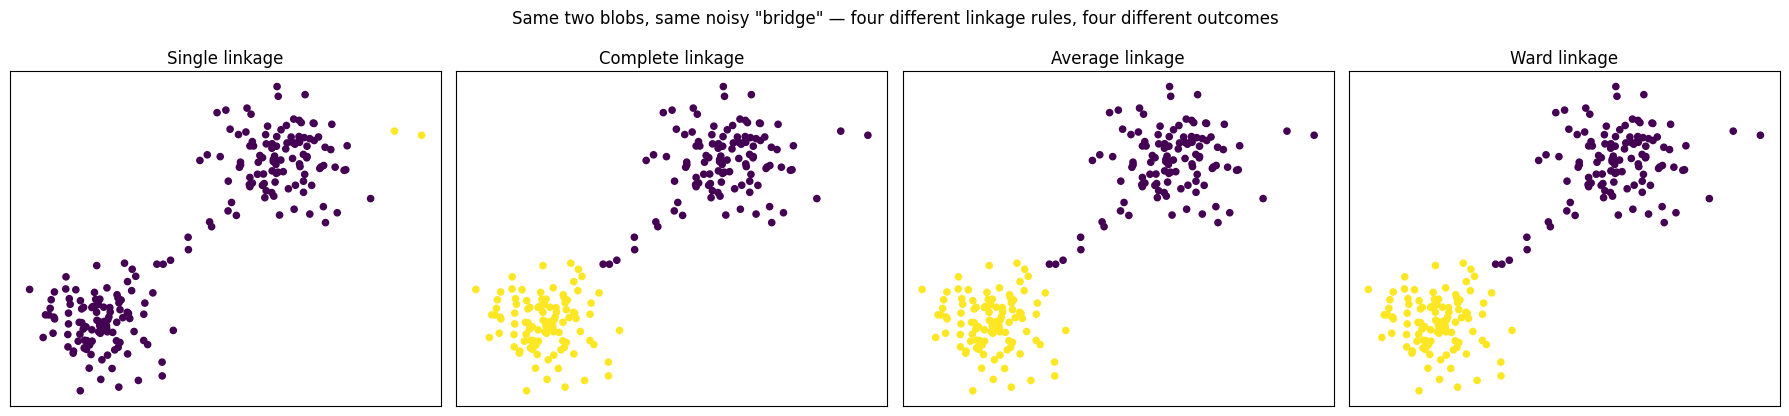

In [5]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

rng = np.random.RandomState(3)
blob_a, _ = make_blobs(n_samples=100, centers=[[0, 0]], cluster_std=1.0, random_state=1)
blob_b, _ = make_blobs(n_samples=100, centers=[[6, 6]], cluster_std=1.0, random_state=2)
bridge_t = np.linspace(0, 1, 20)
bridge = np.column_stack([bridge_t * 6, bridge_t * 6]) + rng.normal(scale=0.15, size=(20, 2))
X_bridge = np.vstack([blob_a, blob_b, bridge])

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, linkage in zip(axes, ["single", "complete", "average", "ward"]):
    labels = AgglomerativeClustering(n_clusters=2, linkage=linkage).fit_predict(X_bridge)
    ax.scatter(X_bridge[:, 0], X_bridge[:, 1], c=labels, cmap="viridis", s=20)
    ax.set_title(f"{linkage.capitalize()} linkage")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Same two blobs, same noisy "bridge" — four different linkage rules, four different outcomes')
plt.tight_layout()
plt.show()

Only single linkage falls for the bridge — it follows the trail of noisy points and merges the two blobs into
one long, chain-like cluster. Complete, average, and Ward all recognize the two blobs as genuinely separate,
because they each look at more than just the single nearest pair of points.

**Comparing the four methods:**

| Method | Uses | Typical shape | Main weakness |
|---|---|---|---|
| Single | Minimum pairwise distance | Long, chain-like | Very sensitive to noisy bridge points |
| Complete | Maximum pairwise distance | Compact and tight | Can over-separate large clusters |
| Average | Mean pairwise distance | Balanced | Computationally more expensive |
| Ward | Increase in variance | Compact, balanced | Works best with Euclidean distance |

Ward linkage is worth calling out: it minimizes the *increase* in within-cluster variance after each merge — the
same idea WCSS/inertia minimization plays for K-Means — which is why it tends to produce compact, balanced
clusters similar in spirit to K-Means's output.


**Quick check**

> Which linkage method is most likely to produce long, chain-like clusters when noisy data connects two otherwise
> separate groups?
>
> **Single linkage** — because it only ever looks at the single closest pair of points between two clusters, one
> noisy bridge point is enough to justify a merge. Complete, average, and Ward all consider more than just the
> nearest pair, so they're harder to fool with a thin trail of noise.


## 4. Reading dendrograms and choosing a cut

With K-Means, you must pick `K` before running the algorithm. Hierarchical clustering gives you something
better: a **dendrogram** — a tree recording every merge, in order, that you can "cut" at any height to choose `K`
*after* seeing the full merge structure.


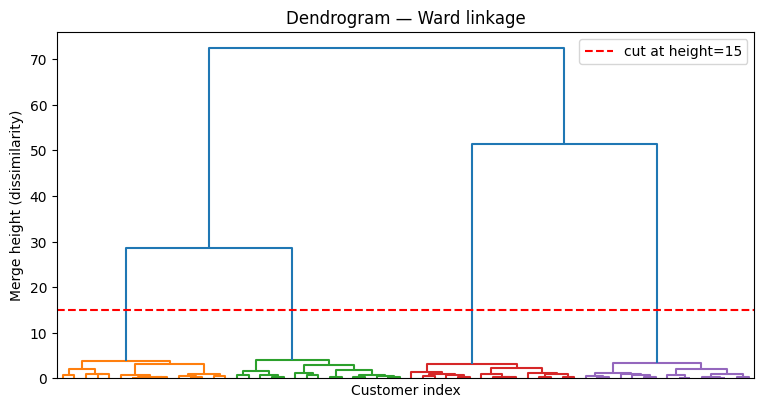

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage, fcluster

X_blobs, _ = make_blobs(n_samples=60, centers=4, cluster_std=0.7, random_state=7)
Z_blobs = scipy_linkage(X_blobs, method="ward")

plt.figure(figsize=(9, 4.5))
dendrogram(Z_blobs, no_labels=True, color_threshold=15)
plt.axhline(15, color="red", linestyle="--", label="cut at height=15")
plt.title("Dendrogram — Ward linkage")
plt.xlabel("Customer index")
plt.ylabel("Merge height (dissimilarity)")
plt.legend()
plt.show()

**How to read it:**

- **Leaves** (bottom) — individual data points.
- **Branches** — merges between clusters.
- **Height of a merge** — how dissimilar the two merged groups were; a low merge happens between very similar
  groups, a high merge joins groups that were already quite different.
- **A horizontal cut** — your choice of `K`. Cut low for more clusters, cut high for fewer.

For this particular dataset, cutting the dendrogram at different heights produces different cluster counts —
very low, and you're back to nearly every point being its own cluster (technically valid, not useful); beyond a
certain height the count stabilizes and stays there across a wide range of cut heights, because the underlying
groups are cleanly separated. The dendrogram doesn't hand you one "right" `K` — it shows you every option at
once, so you can choose.

`fcluster` turns a chosen cut height into actual cluster labels, so the number of clusters at any height is just
a `len(set(...))` away:


In [7]:
def clusters_at_height(Z, height):
    return len(set(fcluster(Z, t=height, criterion='distance')))

for h in [3, 5, 10, 15, 20, 25]:
    print(f"Cut height={h:>2}  ->  {clusters_at_height(Z_blobs, h)} clusters")

Cut height= 3  ->  9 clusters
Cut height= 5  ->  4 clusters
Cut height=10  ->  4 clusters
Cut height=15  ->  4 clusters
Cut height=20  ->  4 clusters
Cut height=25  ->  4 clusters


**Quick check**

> In a dendrogram, what does the height at which two branches merge represent?
>
> How dissimilar (far apart) the two merged clusters were — not the number of customers in each branch, not the
> order customers signed up, and not a value of `K` you're required to use.


## 5. The other direction: divisive (top-down) clustering

Everything so far has been **agglomerative** — bottom-up. There's a mirror-image approach called **divisive
clustering**: start with every point in one giant cluster, and keep splitting the least cohesive cluster in two,
until every point is its own cluster.

Divisive clustering is far less common in practice, for a computational reason: agglomerative only needs to find
the closest pair of *existing* clusters at each step, which is cheap. Divisive needs to find the *best way to
split* a cluster in two — a much harder search problem — so most implementations approximate it with K-Means
rather than solving it exactly. That's exactly what a **bisecting K-Means** implementation of divisive
clustering does: repeatedly pick the cluster with the highest variance (the least cohesive one) and split it into
2 using ordinary K-Means as the splitter.


In [8]:
from sklearn.cluster import KMeans

def bisecting_divisive(X, n_clusters):
    """Divisive clustering: repeatedly split the highest-variance
    cluster into 2, using K-Means as the splitter."""
    clusters = {0: np.arange(len(X))}
    next_id = 1
    history = []

    while len(clusters) < n_clusters:
        target_id = max(
            clusters,
            key=lambda cid: X[clusters[cid]].var(axis=0).sum()
                             if len(clusters[cid]) > 1 else -1
        )
        idx = clusters[target_id]
        if len(idx) <= 1:
            break
        km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X[idx])
        left, right = idx[km.labels_ == 0], idx[km.labels_ == 1]
        del clusters[target_id]
        clusters[next_id], clusters[next_id + 1] = left, right
        history.append((target_id, next_id, next_id + 1, len(left), len(right)))
        next_id += 2

    labels = np.zeros(len(X), dtype=int)
    for new_label, idx in enumerate(clusters.values()):
        labels[idx] = new_label
    return labels, history

_, split_history = bisecting_divisive(toy_points, n_clusters=3)
print("Split order (parent -> child_a, child_b | sizes):")
for step, (parent, child_a, child_b, size_a, size_b) in enumerate(split_history, start=1):
    print(f"Step {step}: cluster {parent} -> {child_a} & {child_b}  |  sizes {size_a}, {size_b}")

Split order (parent -> child_a, child_b | sizes):
Step 1: cluster 0 -> 1 & 2  |  sizes 4, 2
Step 2: cluster 1 -> 3 & 4  |  sizes 2, 2


Running it on the toy six-point dataset from Section 2 shows the top-down logic in action: the first split
separates it into two halves, then the next split breaks the least-cohesive of those halves down further —
working *down* the tree, the opposite direction from the merging in every other section here.

```{mermaid}
graph LR
    subgraph Agglo["Agglomerative (bottom-up)"]
        A1["Every point<br/>its own cluster"] --> A2["Merge upward"] --> A3["One giant cluster"]
    end
    subgraph Div["Divisive (top-down)"]
        B1["One giant cluster"] --> B2["Split downward"] --> B3["Every point<br/>its own cluster"]
    end

    style A1 fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style A2 fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style A3 fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
    style B1 fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
    style B2 fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style B3 fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
```

| | Agglomerative (bottom-up) | Divisive (top-down) |
|---|---|---|
| **Direction** | Merge upward | Split downward |
| **Computational cost** | Cheaper — compares existing clusters | Expensive — searches for the best split at each level |
| **Common in practice?** | Yes — the default choice | Rarely — mainly when only the top of the tree is needed |
| **Library support** | `scipy` / `sklearn` built-in | No dedicated function — usually approximated with recursive K-Means |

On cleanly separated data, both approaches roughly agree, because the clusters are unambiguous either way. On
messier data they can diverge more: divisive clustering's early splits lock in decisions that can't be
undone, so one bad split near the top distorts everything below it.


## 6. Where hierarchical clustering wins: cluster shape

Recall the shape limitation from the [K-Means++ notes](../k-means-plus-plus/notes.ipynb): K-Means can only draw
straight-line boundaries, so moons, rings, and unequal-density blobs all get sliced through incorrectly — no
matter how good the initialization is. Single-linkage hierarchical clustering handles exactly this category of
shape, because it never thinks in centroids at all.


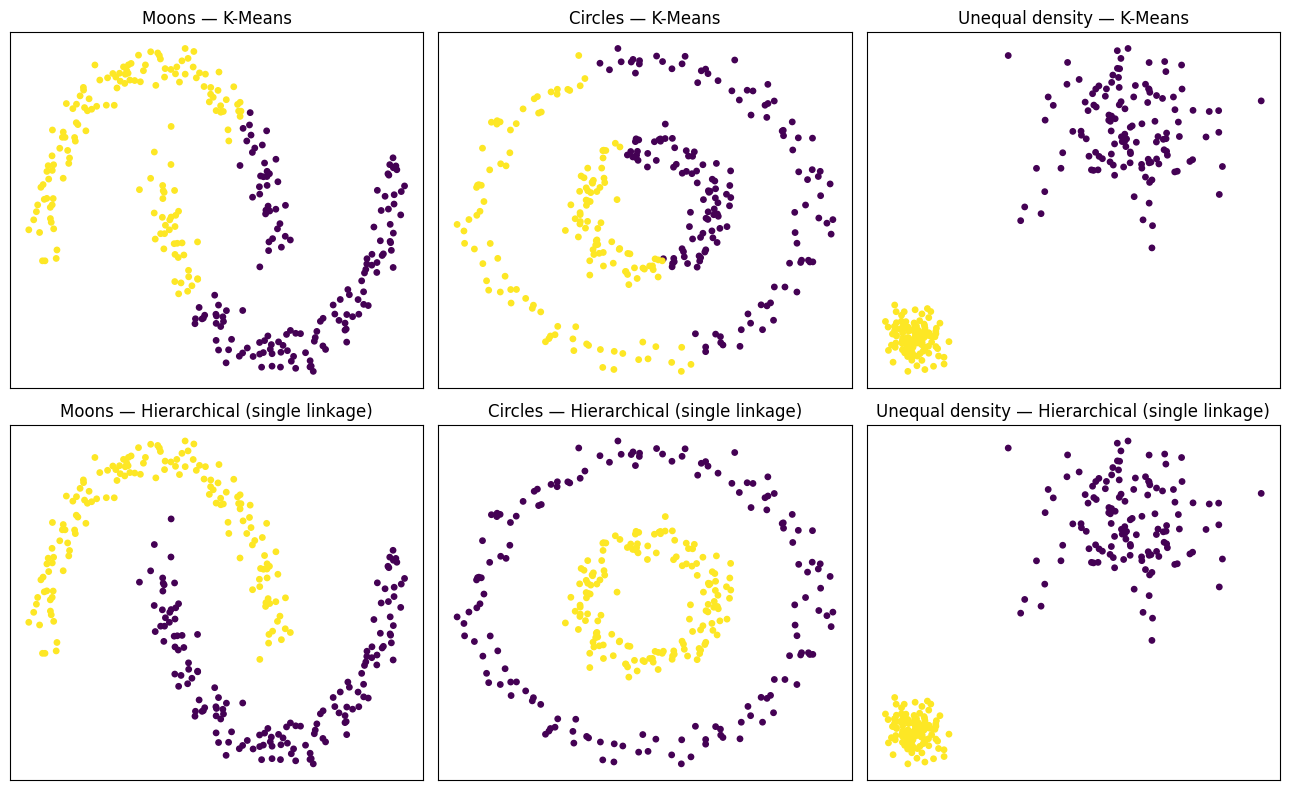

In [9]:
from sklearn.datasets import make_moons, make_circles

X_moons, _ = make_moons(n_samples=300, noise=0.07, random_state=1)
X_circles, _ = make_circles(n_samples=300, factor=0.4, noise=0.06, random_state=1)
X_uneven, _ = make_blobs(n_samples=250, centers=[[0, 0], [6, 6]], cluster_std=[0.4, 1.2], random_state=1)

datasets = [("Moons", X_moons, 2), ("Circles", X_circles, 2), ("Unequal density", X_uneven, 2)]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for col, (title, X, k) in enumerate(datasets):
    km_labels = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=1).fit_predict(X)
    hc_labels = AgglomerativeClustering(n_clusters=k, linkage="single").fit_predict(X)

    axes[0, col].scatter(X[:, 0], X[:, 1], c=km_labels, cmap="viridis", s=15)
    axes[0, col].set_title(f"{title} — K-Means")
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    axes[1, col].scatter(X[:, 0], X[:, 1], c=hc_labels, cmap="viridis", s=15)
    axes[1, col].set_title(f"{title} — Hierarchical (single linkage)")
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
plt.tight_layout()
plt.show()

Across all three, single-linkage hierarchical clustering follows the true shape where K-Means slices straight
through it. The reason is the same "chaining" behavior flagged as a *weakness* on the noisy-bridge dataset in
Section 3 — along a curved, densely packed shape like a moon, chaining neighboring points together is exactly
why it works here.

No linkage — or algorithm — is universally "better." Single linkage's chaining tendency was a liability on the
noisy-bridge dataset and is the winning feature here. The right tool depends on the shape of the problem.


## 7. Applying it: customer segmentation revisited

Back to the underlying business problem from the [K-Means++ notes](../k-means-plus-plus/notes.ipynb): segmenting
customers by annual income against spending score. A centroid-based approach previously produced compact,
roughly spherical customer segments. Here's what hierarchical clustering does with the exact same data —
regenerated with the same income/spending quadrants used there.


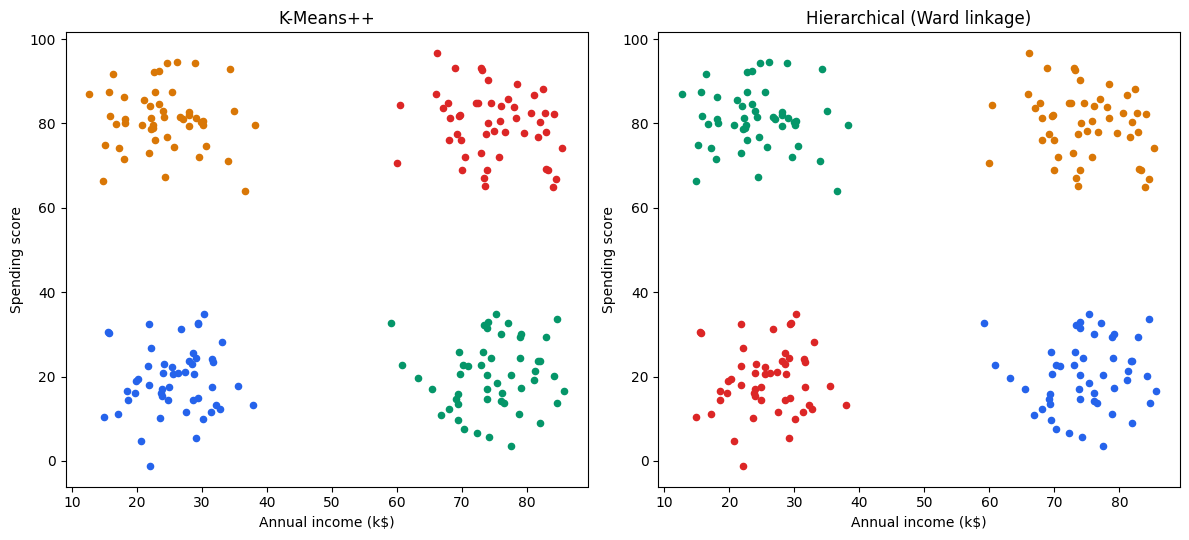

In [10]:
rng = np.random.RandomState(11)
seg_centers = np.array([[25, 20], [25, 80], [75, 20], [75, 80]])
X_customers = np.vstack([
    rng.normal(loc=c, scale=[6, 8], size=(50, 2)) for c in seg_centers
])

km_cust_labels = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=11).fit_predict(X_customers)
hc_cust_labels = AgglomerativeClustering(n_clusters=4, linkage="ward").fit_predict(X_customers)

colors = ["#2563EB", "#DC2626", "#059669", "#D97706"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for j in range(4):
    axes[0].scatter(X_customers[km_cust_labels == j, 0], X_customers[km_cust_labels == j, 1], s=20, color=colors[j])
    axes[1].scatter(X_customers[hc_cust_labels == j, 0], X_customers[hc_cust_labels == j, 1], s=20, color=colors[j])
axes[0].set_title("K-Means++"); axes[1].set_title("Hierarchical (Ward linkage)")
for ax in axes:
    ax.set_xlabel("Annual income (k$)"); ax.set_ylabel("Spending score")
plt.tight_layout()
plt.show()

Both algorithms land on similar segments here — expected, since this data is cleanly separated into four
quadrants either way. The difference is *how* they got there:

- **K-Means++** picked 4 spread-out starting centroids up front, then assigned every customer to its nearest one.
- **Hierarchical clustering** never picked a center at all — it built the segments up from individual customers,
  merging the most similar pairs first, all the way up to 4 groups.

The real payoff of the hierarchical approach doesn't show up on data this clean — it shows up in *not knowing*
`K = 4` in advance. Without that assumption, the dendrogram for this dataset would have revealed the choice of 4
segments directly, instead of forcing a guess upfront the way K-Means requires.


## 8. Where hierarchical clustering shows up in real life

"Build a tree by merging similar things" shows up far outside customer segmentation:

- **Biology** — grouping genes or species by similarity produces a tree of relatedness; this is literally how
  evolutionary family trees are built, using the same merge-by-similarity idea.
- **Document organization** — grouping articles or support tickets into nested topics and sub-topics ("Billing"
  → "Refunds" → "Late refund complaints") is a dendrogram in disguise.
- **Social networks** — finding communities within a friend or follower network, where tight-knit friend groups
  merge into looser social circles, is agglomerative clustering applied to relationships instead of coordinates.
- **Org charts** — read in reverse, a company's org chart is a dendrogram top-down: individual employees roll up
  into teams, into departments, into the whole company.

In every one of these, "no fixed `K` upfront" isn't a limitation — it's the entire point. Nobody knows in advance
exactly how many species, topics, communities, or departments there "should" be.


## 9. Choosing the right algorithm

| | K-Means (++) | Hierarchical |
|---|---|---|
| **Speed** | Fast, scales to large data | Slower, doesn't scale as well |
| **Need K upfront?** | Yes | No — decide from the dendrogram |
| **Cluster shape** | Spherical / convex only | Handles more complex structures |
| **Best for** | Large, frequently-refreshed datasets | Smaller, exploratory analysis |

**A scenario to test the trade-off:** a retailer has 5 million customer records, updated every night, and the
team already knows they want exactly 6 customer segments. Which algorithm is the better production choice?

**K-Means++** — it scales to large, frequently-updated data, and since `K` is already known, hierarchical
clustering's main advantage (not needing `K` upfront) doesn't even apply here. Hierarchical clustering also
doesn't scale well enough to comfortably handle millions of rows, nightly.

The general recommendation follows from this: keep using K-Means++ for large-scale, day-to-day segmentation,
since it's fast and reliable. For smaller, exploratory analyses where the right number of segments isn't known
yet, hierarchical clustering — and its dendrogram — gives room to explore before committing to a number.


**Hands-on exercise (no code)**

A data science team is exploring a brand-new, messy dataset for the first time. They don't yet know how many
natural segments exist, and the dataset is small enough to process without performance concerns. Which approach —
and which linkage method — best fits this situation? Reason through it before checking below.

> **Answer:** Hierarchical clustering with Ward linkage, so they can explore the dendrogram before committing to
> `K`. K-Means++ isn't wrong exactly, but "always the safer default" isn't a real reason when `K` isn't even
> known yet — and single linkage, while simple, is the wrong pick here since nothing in the scenario suggests the
> data has the thin, chain-connected shape single linkage is actually good at finding.


## 10. Summary — revision cheat sheet

**The big idea:** hierarchical clustering builds clusters by merging (agglomerative) or splitting (divisive),
instead of assigning points to centroids. No centers, no fixed `K` upfront — just repeated merging, one pair at a
time, until everything has merged into one giant cluster.

**The algorithm:** start with every point as its own cluster → find the two closest clusters → merge them →
repeat until one cluster remains. See Section 2 for the full walkthrough.

**Linkage criteria** — control how the distance between two *clusters* (not points) is measured:
- *Single* — minimum pairwise distance; chains, sensitive to noisy bridges.
- *Complete* — maximum pairwise distance; tight, compact clusters.
- *Average* — mean pairwise distance; balanced, more expensive.
- *Ward* — increase in within-cluster variance; compact and balanced, closest in spirit to K-Means.

**Dendrograms** let you choose `K` *after* seeing the full merge structure, instead of committing to it upfront
the way K-Means requires — cut low for more clusters, cut high for fewer. `clusters_at_height` (Section 4) turns
any cut height into an actual cluster count.

**Divisive clustering** is the top-down mirror image of everything above — rarer in practice, since finding the
best way to *split* a cluster is a harder search problem than finding the closest *pair* to merge; a
bisecting-K-Means implementation (Section 5) is the common way to approximate it.

**Where it wins:** non-spherical, non-convex shapes — moons, circles, uneven density — that break K-Means's
centroid assumption, because hierarchical clustering never uses a centroid at all. On cleanly-separated data
(Section 7), it lands on similar segments to K-Means++ — the difference shows up in *not* needing `K` upfront.

**Where K-Means still wins:** large, frequently-refreshed datasets where `K` is already known and speed matters —
hierarchical clustering doesn't scale as well.

**Not yet covered (coming in later sessions):** DBSCAN and PCA.

**Next up:** the [Gaussian Mixture Models notes](../gaussian-mixture-models/notes.ipynb) — Hierarchical Clustering
doesn't scale to very large datasets and still forces every point into exactly one cluster; GMM fixes both by
giving every point a *probability* of belonging to each cluster instead of a single hard label.
